<a href="https://colab.research.google.com/github/suyogbastakoti/Ai-and-Ml-Module/blob/main/2407093_SuyogBastakoti_Worksheet5_CNN_FruitImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Worksheet 5: End-to-End CNN for Fruit Image Classification

**Module:** Artificial Intelligence and Machine Learning  
**Task:** Build a CNN to classify Amazon fruits using TensorFlow & Keras

---

## 📋 What we will do (Step by Step):
1. Download and set up the dataset
2. Visualize images from each class
3. Check for corrupted images
4. Load and preprocess the data
5. Build the CNN model
6. Compile the model
7. Train the model
8. Evaluate the model
9. Save and reload the model
10. Make predictions and generate classification report

We install/import everything we need here.

In [1]:
# ── Check if GPU is available ──────────────────────────────────────────────
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import all required libraries
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
## Step 1: Load the Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#unzip from Drive:
!unzip -q "/content/drive/MyDrive/Data Set /FruitinAmazon.zip" -d ./dataset

In [8]:
# ── Find the train and test directories ────────────────────────────────────
# Walk through the dataset folder to find where train/test folders are

dataset_root = './dataset'

for root, dirs, files_list in os.walk(dataset_root):
    # Only show top 2 levels
    level = root.replace(dataset_root, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 2:
            subindent = ' ' * 2 * (level + 1)
            for d in dirs:
                print(f'{subindent}{d}/')

dataset/
  FruitinAmazon/
  FruitinAmazon/
    test/
    train/
    test/
    train/


In [9]:
#Set your train and test directory paths

# Example: if you see dataset/fruits/train → set train_dir = './dataset/fruits/train'

train_dir = '/content/dataset/FruitinAmazon/train'
test_dir  = '/content/dataset/FruitinAmazon/test'

# Verify the directories exist
print("Train directory exists:", os.path.isdir(train_dir))
print("Test directory exists: ", os.path.isdir(test_dir))

# Print the class names (folder names inside train)
class_names = sorted(os.listdir(train_dir))
print("\nClasses found:", class_names)
print("Number of classes:", len(class_names))

Train directory exists: True
Test directory exists:  True

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
## Task 1A: Visualize One Image from Each Class

We randomly pick one image from each class and display them in a grid.

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


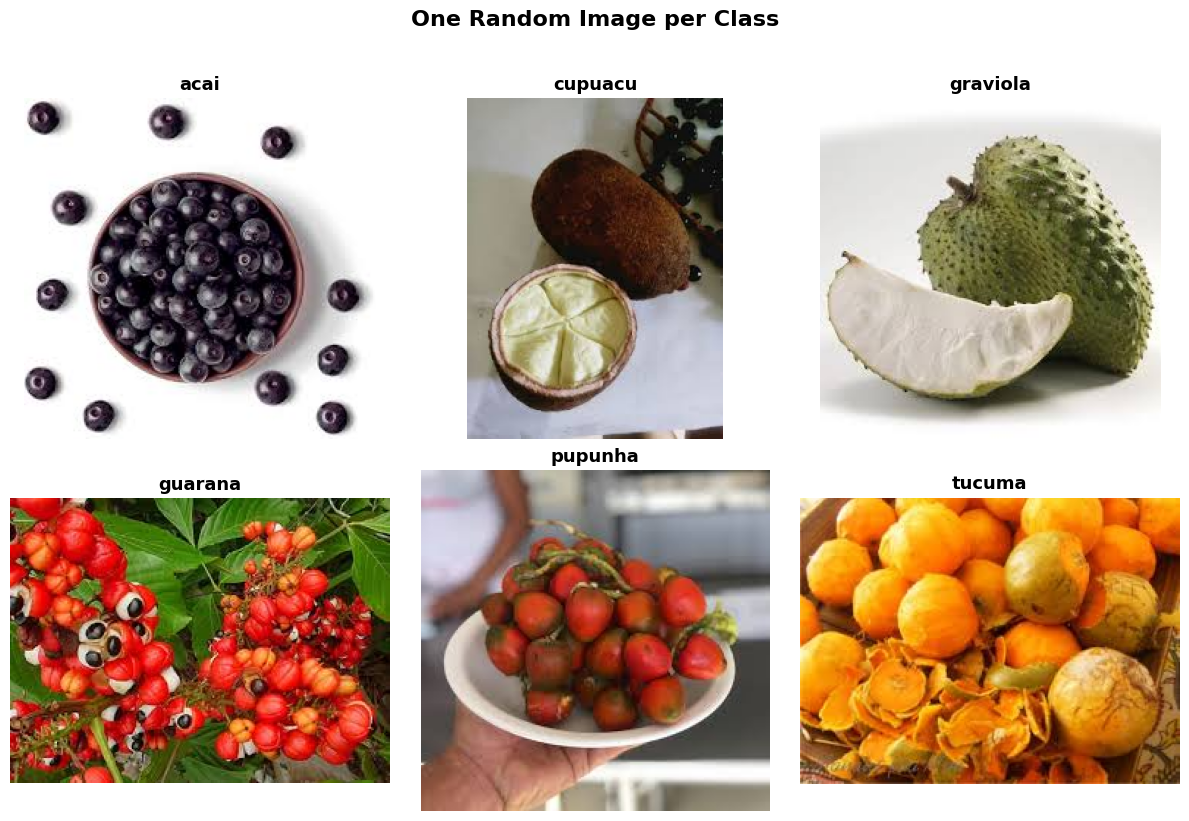

In [11]:
# Task 1: Load and Visualize Images

# Step 1: Get the list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Found {len(class_dirs)} classes: {class_dirs}")

# Step 2: Select one random image from each class
selected_images = []   # will hold (class_name, image_path) pairs

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)
    # List all image files in this class folder
    all_images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    # Pick one randomly
    random_image = random.choice(all_images)
    full_path = os.path.join(class_path, random_image)
    selected_images.append((class_name, full_path))

# Step 3: Display in a grid with 2 rows
num_classes = len(selected_images)
cols = (num_classes + 1) // 2   # number of columns = half the classes (rounded up)
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()   # flatten so we can loop easily

for i, (class_name, img_path) in enumerate(selected_images):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=13, fontweight='bold')
    axes[i].axis('off')

# Hide any leftover empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One Random Image per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Observation
# Answer the question: What did you observe?

print("""
📝 OBSERVATIONS:
1. The dataset contains 6 different Amazon fruit classes.
2. Images vary in size, background colour, and lighting.
3. Some fruits look visually similar (e.g., round fruits),
   which could make classification challenging.
4. Images have different resolutions — preprocessing
   (resizing) will be needed to standardise them.
5. No obvious corruptions visible in the sampled images.
""")

---
## Task 1B: Check for Corrupted Images

We try to open every image. If it fails, we remove it and print a message.

In [12]:
# ── Task 1B: Remove Corrupted Images ──────────────────────────────────────

corrupted_images = []   # list to store paths of corrupted images

# Iterate through every class subdirectory in train
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue   # skip if it's not a folder

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            # Try to open the image — if it's corrupted this will raise an error
            img = Image.open(image_path)
            img.verify()   # verify checks the file integrity without fully decoding

        except (IOError, SyntaxError):
            # Image is corrupted!
            corrupted_images.append(image_path)
            os.remove(image_path)   # Remove the corrupted file
            print(f"Removed corrupted image: {image_path}")

# Final report
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\n Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2: Load and Preprocess the Data

We use Keras's `image_dataset_from_directory` to:
- Resize all images to the same size (128×128)
- Split training data into train (80%) and validation (20%)
- Normalise pixel values from [0, 255] → [0, 1]

In [13]:
# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_HEIGHT       = 128    # resize all images to 128 pixels tall
IMG_WIDTH        = 128    # resize all images to 128 pixels wide
BATCH_SIZE       = 32     # number of images per batch
VALIDATION_SPLIT = 0.2    # 20% of training data used for validation
SEED             = 123    # for reproducibility

print(f"Image size   : {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Val split    : {VALIDATION_SPLIT * 100}%")

Image size   : 128 x 128
Batch size   : 32
Val split    : 20.0%


In [14]:
# ── Create Training Dataset ────────────────────────────────────────────────
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',       # use folder names as labels
    label_mode      = 'int',            # labels as integers (0, 1, 2 ...)
    image_size      = (IMG_HEIGHT, IMG_WIDTH),
    interpolation   = 'nearest',
    batch_size      = BATCH_SIZE,
    shuffle         = True,             # shuffle training data
    validation_split= VALIDATION_SPLIT,
    subset          = 'training',
    seed            = SEED
)

print("Training dataset created!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Training dataset created!


In [15]:
# ── Create Validation Dataset ──────────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (IMG_HEIGHT, IMG_WIDTH),
    interpolation   = 'nearest',
    batch_size      = BATCH_SIZE,
    shuffle         = False,            # do NOT shuffle validation data
    validation_split= VALIDATION_SPLIT,
    subset          = 'validation',
    seed            = SEED
)

print("Validation dataset created!")

Found 90 files belonging to 6 classes.
Using 18 files for validation.
Validation dataset created!


In [16]:
# ── Create Test Dataset ─────────────────────────────────────────────────────
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels      = 'inferred',
    label_mode  = 'int',
    image_size  = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

# Save class names from the dataset
class_names = train_ds.class_names
num_classes = len(class_names)

print("Test dataset created!")
print(f"\nClass names  : {class_names}")
print(f"Num classes  : {num_classes}")

Found 30 files belonging to 6 classes.
Test dataset created!

Class names  : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes  : 6


In [17]:
#Normalise pixel values from [0,255] to [0,1]
# Neural networks train better with small numbers

rescale = tf.keras.layers.Rescaling(1.0 / 255)   # divide by 255

# Apply normalisation to all three datasets
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

# Speed up loading with prefetch (loads next batch while training on current)
AUTOTUNE  = tf.data.AUTOTUNE
train_ds  = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds    = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds   = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Normalisation applied to all datasets!")

Normalisation applied to all datasets!


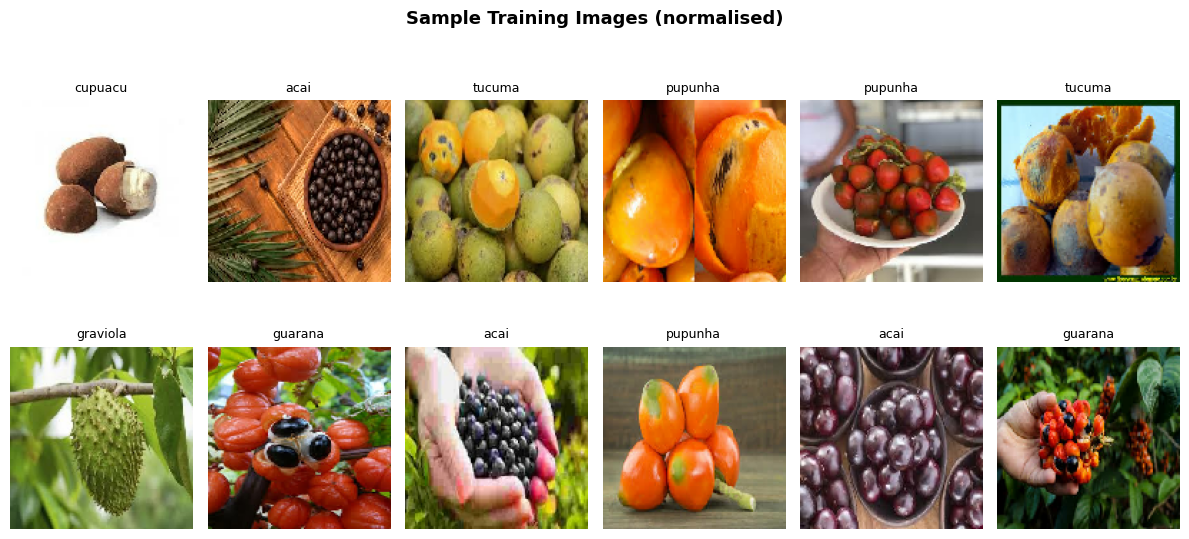

In [18]:
# Quick sanity check: show a batch of images
plt.figure(figsize=(12, 6))

for images, labels in train_ds.take(1):   # take just 1 batch
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')

plt.suptitle('Sample Training Images (normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏗️ Task 3: Build the CNN Model

We follow the exact architecture from the worksheet:
```
Conv2D(32, 3×3, same) → ReLU → MaxPool(2×2)
Conv2D(32, 3×3, same) → ReLU → MaxPool(2×2)
Flatten
Dense(128) → ReLU
Dense(64)  → ReLU
Dense(num_classes) → Softmax
```

In [19]:
# ── Task 3: Build the CNN ──────────────────────────────────────────────────

model = keras.Sequential([

    # ── Block 1 ──
    # Convolutional Layer 1: 32 filters, 3×3 kernel, same padding
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu',           # ReLU activation
        input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)   # 3 channels = colour image
    ),
    # Max Pooling Layer 1: 2×2 pool, stride 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Block 2 ───
    # Convolutional Layer 2: 32 filters, 3×3 kernel, same padding
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu'
    ),
    # Max Pooling Layer 2: 2×2 pool, stride 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Section ──
    # Flatten: converts 3D feature maps into a 1D vector
    layers.Flatten(),

    # Hidden Layer 1: 128 neurons
    layers.Dense(128, activation='relu'),

    # Hidden Layer 2: 64 neurons
    layers.Dense(64, activation='relu'),

    # Output Layer: one neuron per class, softmax gives probabilities
    layers.Dense(num_classes, activation='softmax')
])

# Print the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile the Model

- **Optimizer:** Adam (adjusts learning rate automatically)
- **Loss:** Sparse Categorical Cross-Entropy (for integer labels)
- **Metric:** Accuracy

In [20]:
# ── Task 4: Compile ──

model.compile(
    optimizer = 'adam',                         # Adam optimizer
    loss      = 'sparse_categorical_crossentropy',  # works with integer labels
    metrics   = ['accuracy']                    # track accuracy during training
)

print("Model compiled!")

Model compiled!


---
## Task 4 (continued): Train the Model

We use two **callbacks** to improve training:
- **ModelCheckpoint:** saves the best model (best validation accuracy)
- **EarlyStopping:** stops training if val accuracy stops improving (prevents overfitting)

> Training 250 epochs may take 10-30 minutes on GPU.

In [21]:
# ── Task 4: Train ──

EPOCHS     = 250
BATCH_SIZE = 16   # as specified in the worksheet

# ── Callback 1: Save the best model automatically ──
checkpoint_cb = ModelCheckpoint(
    filepath        = 'best_model.h5',       # save to this file
    monitor         = 'val_accuracy',        # watch validation accuracy
    save_best_only  = True,                  # only save when it improves
    verbose         = 1
)

# ── Callback 2: Stop early if no improvement ──
earlystop_cb = EarlyStopping(
    monitor   = 'val_accuracy',    # watch validation accuracy
    patience  = 20,                # stop after 20 epochs with no improvement
    restore_best_weights = True,   # restore weights from the best epoch
    verbose   = 1
)

# ── Train! ──
print("Starting training...")
print(f" Max epochs  : {EPOCHS}")
print(f" Batch size  : {BATCH_SIZE}")
print(" (Training will stop early if val_accuracy stops improving)\n")

history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, earlystop_cb],
    verbose         = 1
)

print("\nTraining complete!")

Starting training...
 Max epochs  : 250
 Batch size  : 16
 (Training will stop early if val_accuracy stops improving)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.1898 - loss: 2.0927
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1944 - loss: 2.2116 - val_accuracy: 0.0000e+00 - val_loss: 1.7934
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2500 - loss: 1.8671
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2639 - loss: 1.8386 - val_accuracy: 0.1111 - val_loss: 1.4338
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2500 - loss: 1.5961
Epoch 3: val_accuracy did not improve from 0.11111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3194 - loss: 1.5054 - val_accuracy: 0.0000e+00 - val_loss: 1.6780
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 1.2609
Epoch 4: val_accuracy improved from 0.11111 to 0.16667, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5139 - loss: 1.2461 - val_accuracy: 0.1667 - val_loss: 1.4876
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5938 - loss: 1.1660
Epoch 5: val_accuracy improved from 0.16667 to 0.88889, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7222 - loss: 0.9800 - val_accuracy: 0.8889 - val_loss: 0.8264
Epoch 6/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8438 - loss: 0.6562
Epoch 6: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7639 - loss: 0.7444 - val_accuracy: 0.7222 - val_loss: 0.9384
Epoch 7/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9062 - loss: 0.5296
Epoch 7: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8472 - loss: 0.5349 - val_accuracy: 0.7222 - val_loss: 0.6871
Epoch 8/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8750 - loss: 0.3721
Epoch 8: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8611 - loss: 0.3569 - val_accuracy: 0.9444 - val_loss: 0.3165
Epoch 9/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9688 - loss: 0.2310
Epoch 9: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9861 - loss: 0.2384 - val_accuracy: 0.7222 - val_loss: 0.8904
Epoch 10/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9375 - loss: 0.1802
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9583 - loss: 0.1768 - val_accuracy: 0.8333 - val_loss: 0.4587
Epoch 11/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9375 - loss: 0.1010
Epoch 11: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9583 - loss: 0.1095 - val_accuracy: 0.8889 - val_loss: 0.2795
Epoch 12/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.053

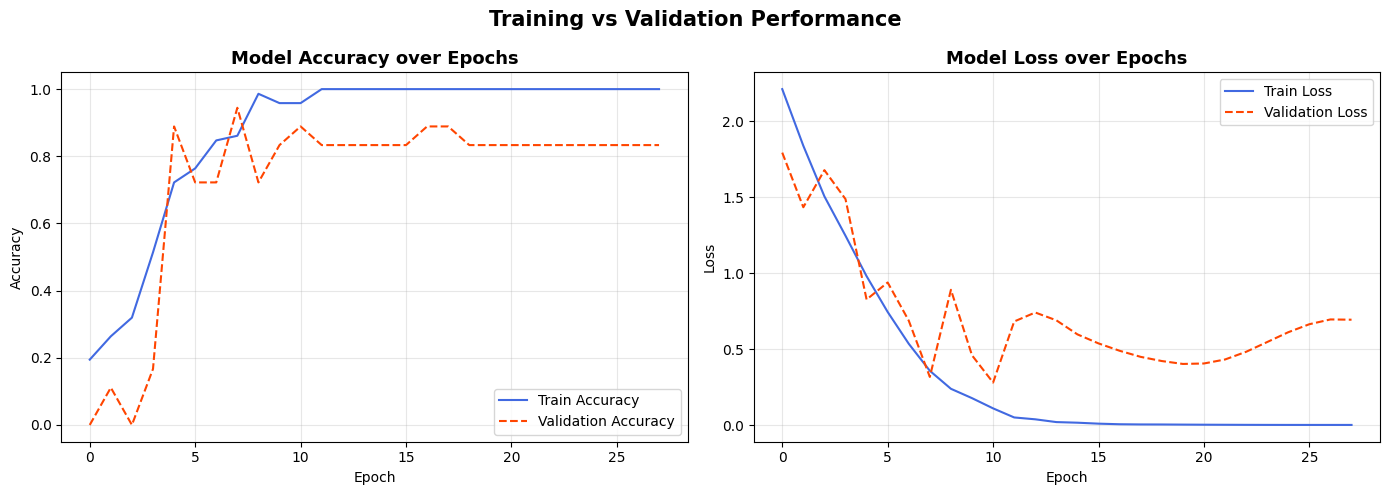

Training curves saved as 'training_curves.png'


In [22]:
# ── Plot Training History ──
# Visualise how accuracy and loss changed over epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy plot ──
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orangered', linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss plot ──
axes[1].plot(history.history['loss'],     label='Train Loss',      color='royalblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orangered', linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as 'training_curves.png'")

---
## Task 5: Evaluate the Model

We evaluate the **best saved model** on the test set.

In [23]:
# ── Task 5: Evaluate on Test Set ──

print("Evaluating on test set...\n")

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"{'='*40}")

Evaluating on test set...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step - accuracy: 0.6667 - loss: 0.8471

  Test Loss     : 0.8471
  Test Accuracy : 66.67%


---
## Task 6: Save and Load the Model

We save the model to a `.h5` file and then reload it to confirm it works.

In [24]:
# ── Task 6A: Save the Model ───

model.save('fruit_cnn_model.h5')
print("Model saved as 'fruit_cnn_model.h5'")

Model saved as 'fruit_cnn_model.h5'


In [25]:
# ── Task 6B: Load the Model and Re-evaluate ──

loaded_model = keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded successfully!\n")

# Re-evaluate with the loaded model to confirm it works
reloaded_loss, reloaded_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Reloaded Model Test Loss : {reloaded_loss:.4f}")
print(f"  Reloaded Model Test Acc  : {reloaded_acc * 100:.2f}%")
print(f"{'='*40}")
print("\nLoaded model gives same results — saving/loading works correctly!")

Model loaded successfully!

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step - accuracy: 0.6667 - loss: 0.8471

  Reloaded Model Test Loss : 0.8471
  Reloaded Model Test Acc  : 66.67%

Loaded model gives same results — saving/loading works correctly!


In [26]:
# ── Download the saved model file ────

from google.colab import files
files.download('fruit_cnn_model.h5')
print("Model downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded to your computer!


---
## Task 7: Make Predictions & Classification Report

- Use `model.predict()` to get probabilities for each class
- Use `np.argmax()` to pick the class with the highest probability
- Use `classification_report` to see precision, recall, and F1-score

In [27]:
# ── Task 7A: Get predictions and true labels ──

print("Making predictions on test set...")

all_predictions = []   # predicted class indices
all_true_labels = []   # actual class indices

# Loop through all batches in the test dataset
for images, labels in test_ds:
    # model.predict returns probabilities for each class
    probs = loaded_model.predict(images, verbose=0)
    # np.argmax picks the index of the highest probability = predicted class
    predicted_classes = np.argmax(probs, axis=1)

    all_predictions.extend(predicted_classes.tolist())
    all_true_labels.extend(labels.numpy().tolist())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

print(f"Predictions done! Total test images: {len(all_predictions)}")

Making predictions on test set...
Predictions done! Total test images: 30


In [28]:
# ── Task 7B: Print Classification Report ──────────────────────────────────

print("\n" + "="*55)
print("        CLASSIFICATION REPORT")
print("="*55)

report = classification_report(
    all_true_labels,
    all_predictions,
    target_names = class_names
)

print(report)
print("="*55)


        CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.67      0.80      0.73         5
     guarana       1.00      0.40      0.57         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.33      0.60      0.43         5

    accuracy                           0.67        30
   macro avg       0.79      0.67      0.68        30
weighted avg       0.79      0.67      0.68        30



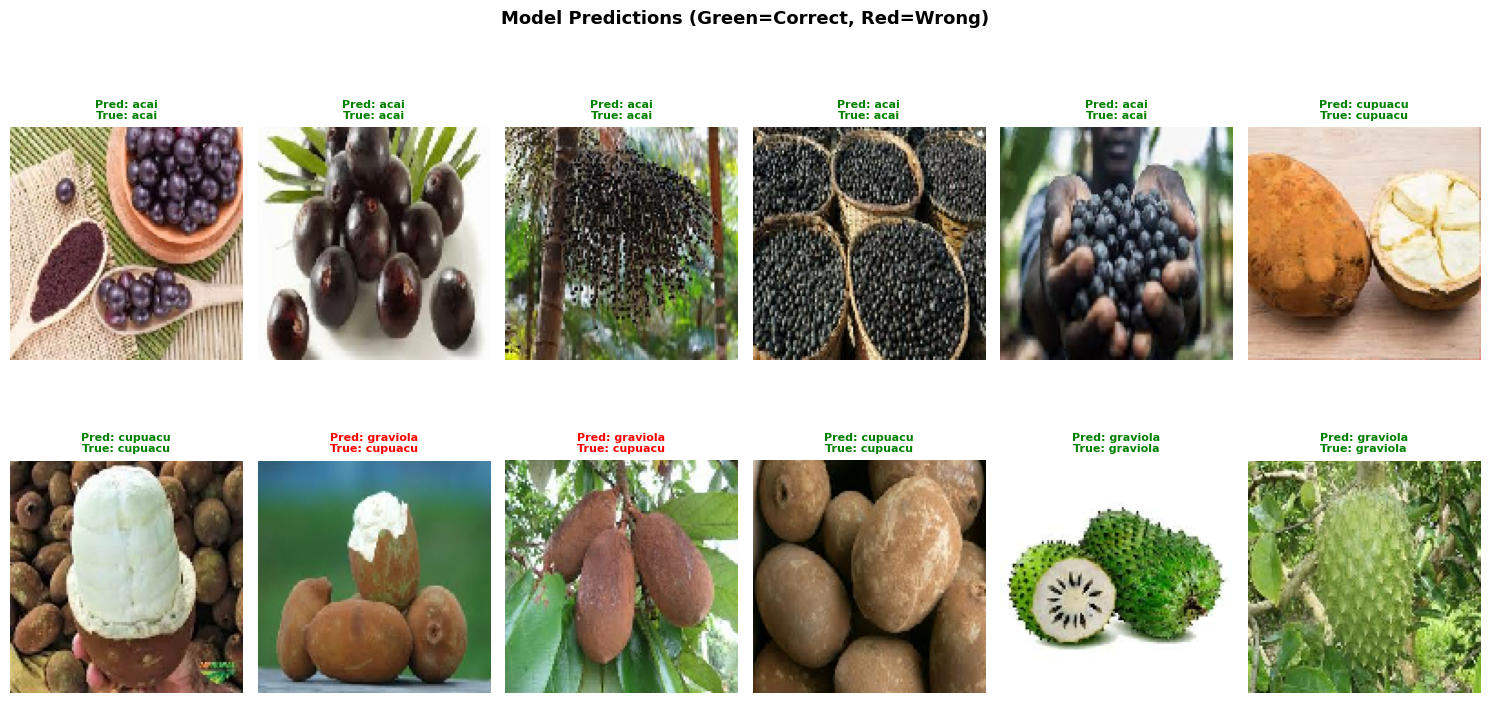

Prediction visualisation saved as 'predictions_sample.png'


In [29]:
# ── Task 7C: Visualise Predictions on Sample Images ──
# Shows 12 test images with their predicted vs actual label

plt.figure(figsize=(15, 8))

sample_count = 0
for images, labels in test_ds.take(1):   # take 1 batch
    probs   = loaded_model.predict(images, verbose=0)
    preds   = np.argmax(probs, axis=1)

    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy())

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]
        correct    = true_label == pred_label

        # Green title = correct, Red = wrong
        color = 'green' if correct else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}",
                  color=color, fontsize=8, fontweight='bold')
        plt.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction visualisation saved as 'predictions_sample.png'")

---
## Final: Download All Output Files

Download the saved model and plots.

In [30]:
# ── Download all deliverables ───
from google.colab import files

for filename in ['fruit_cnn_model.h5', 'best_model.h5',
                 'training_curves.png', 'predictions_sample.png']:
    if os.path.exists(filename):
        files.download(filename)
        print(f"Downloaded: {filename}")
    else:
        print(f"File not found (skipping): {filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fruit_cnn_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: predictions_sample.png


---
## Summary of Deliverables

| Deliverable | Status |
|---|---|
| Task 1: Visualise images from each class | ✅
| Task 1: Corrupted image check | ✅
| Task 2: Data loading & preprocessing | ✅
| Task 3: CNN model built (per spec) | ✅
| Task 4: Model compiled | ✅
| Task 4: Model trained (250 epochs + callbacks) | ✅
| Task 5: Model evaluated on test set | ✅
| Task 6: Model saved as `.h5` and reloaded | ✅
| Task 7: Predictions + Classification Report | ✅
| Visualisation: Training & validation curves | ✅